In [1]:
import itertools
import sys
import ifcopenshell
import networkx as nx


W = ifcopenshell.ifcopenshell_wrapper
schema = W.schema_by_name("IFC4X3_ADD2")
G = nx.DiGraph()
for decl in schema.declarations():
    if isinstance(decl, W.entity):
        for attr in decl.all_attributes():
            ty = attr.type_of_attribute()
            while isinstance(ty, W.aggregation_type):
                ty = ty.type_of_element()
            while isinstance(ty, W.named_type):
                ty = ty.declared_type()
            if isinstance(ty, (W.entity, W.select_type)):
                # only entity, using types (e.g IfcLabel) makes no sense
                G.add_edge(decl.name(), ty.name(), name=f"--{attr.name()}-->")

        # Getting inverse attributes
        for attr in decl.all_inverse_attributes():
            ty = attr.entity_reference()
            while isinstance(ty, W.aggregation_type):
                ty = ty.type_of_element()
            while isinstance(ty, W.named_type):
                ty = ty.declared_type()
            if isinstance(ty, (W.entity, W.select_type)):
                # only entity, using types (e.g IfcLabel) makes no sense
                G.add_edge(decl.name(), ty.name(), name=f"--{attr.name()}-->")
        if st := decl.supertype():
            G.add_edge(st.name(), decl.name(), name="<--inh--")
            # print(f"{st.name()} <--inh-- {decl.name()}")
            # print(f"en: {decl.name()} --- ty: {ty}")

        elif isinstance(decl, W.select_type):
            for d in decl.select_list():
                G.add_edge(decl.name(), d.name(), name="<--impl--")



# Explicit start and end nodes
start_node = "IfcWall"
end_node = "IfcWallType"
# Find the shortest path
pth = nx.shortest_path(G, start_node, end_node)


#pth = nx.shortest_path(G, *sys.argv[1:])
args = [G.edges[pth[i], pth[i + 1]]["name"] for i in range(len(pth) - 1)]
print(*[*itertools.chain.from_iterable(zip(pth, [*args, ""]))])

IfcWall --IsTypedBy--> IfcRelDefinesByType --RelatingType--> IfcTypeObject <--inh-- IfcTypeProduct <--inh-- IfcElementType <--inh-- IfcBuiltElementType <--inh-- IfcWallType 


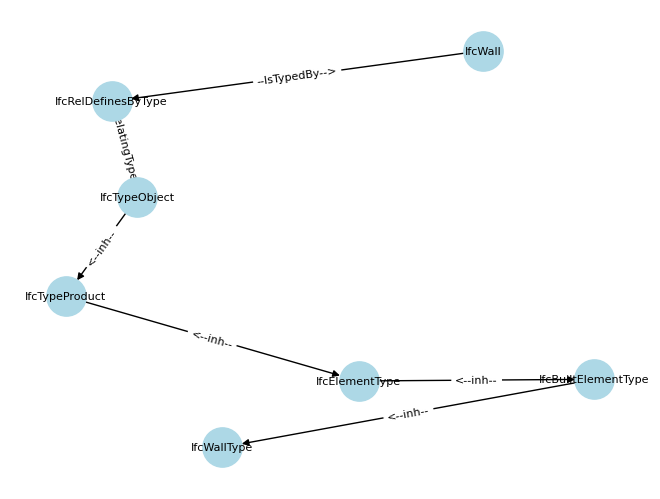

In [2]:
# ---- Create subgraph with only the shortest path ----
# Get edges in path
path_edges = [(pth[i], pth[i + 1]) for i in range(len(pth) - 1)]

# Create a new graph with just the path
G_path = G.edge_subgraph(path_edges).copy()

# ---- Draw only the shortest path ----
import matplotlib.pyplot as plt

pos = nx.spring_layout(G_path)
nx.draw(G_path, pos, with_labels=True, node_size=800, font_size=8, node_color='lightblue')
edge_labels = {(u, v): d['name'] for u, v, d in G_path.edges(data=True)}
nx.draw_networkx_edge_labels(G_path, pos, edge_labels=edge_labels, font_size=8)

plt.show()